# 回归模型评估

系统学习回归模型的评估方法，从核心概念到具体指标，再到代码实践，让你不仅能看懂评估报告，更能亲手为你的模型"打分"。

----

## 回归模型与评估的核心概念
在深入指标之前，我们需要理解几个基础概念，它们是所有评估方法的基石。

### 什么是回归模型？
回归问题是监督学习的一种，其目标是基于输入特征预测一个连续的数值。例如，预测房价、股票价格或温度等。

### 为什么需要评估回归模型？
- 1. 模型选择：评估帮助我们比较不同模型的性能，选择最适合我们数据和任务的模型。
- 2. 参数调优：评估模型的参数配置，找到最佳的参数值，以获得模型的最好性能。
- 3. 性能确认：评估模型在独立数据上的性能，确认模型的泛化能力。

### 关键术语 : 误差
所有评估指标都围绕着"误差"展开。误差是模型预测值（ŷ）与真实值（y）之间的差异。
- 单个点的误差 : 误差 = y - ŷ 
- 评估的本质 : 用不同的方式汇总这些误差，来衡量模型的整体性能。

----

## 核心评估指标
我们将介绍最常用、最重要的几个评估指标，并用一个简单的例子贯穿始终。

假设我们预测了 5 个房子的价格：

| 真实价格（y） | 预测价格（ŷ） | 误差（y - ŷ） |
|---:|---:|---:|
| 200 | 210 | -10 |
| 150 | 145 | 5 |
| 300 | 310 | -10 |
| 400 | 380 | 20 |
| 250 | 255 | -5 |


### 1. 均方误差（MSE）
均方误差是最常用的回归评估指标之一，它计算了预测值与真实值之间误差的平方的平均值。
$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

计算示例:
$$ MSE = \frac{1}{5} [(-10)^2 + 5^2 + (-10)^2 + 20^2 + (-5)^2] = \frac{1}{5} [100 + 25 + 100 + 400 + 25] = \frac{650}{5} = 130 $$

特点 :
- 优点 : 对较大的误差更敏感，适合对大误差进行惩罚的场景。数学性质优秀（处处可导），是许多模型（如线性回归）训练时最小化的目标函数。 
- 量纲与原始数据不同，数值大小不易解释；对异常值敏感。


### 2. 均方根误差（RMSE）
均方根误差是均方误差的平方根，保持了与原始数据相同的量纲，更易于解释。
$$ RMSE = \sqrt{MSE} $$
计算示例:
$$ RMSE = \sqrt{130} \approx 11.4 $$
解读: 平均来看，模型的预测值与真实值之间的误差约为 11.4 单位。

特点 :
- 具有和原始数据相同的量纲，解释性比MSE强；对大误差惩罚更重，在重视大误差的场景（如金融风险预测）中很常用。
- 对异常值敏感，可能会被极端误差拉高。

### 3. 平均绝对误差（MAE）
平均绝对误差计算了预测值与真实值之间误差的绝对值的平均值。
$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$
计算示例:   
$$ MAE = \frac{1}{5} [|(-10)| + |5| + |(-10)| + |20| + |(-5)|] = \frac{1}{5} [10 + 5 + 10 + 20 + 5] = \frac{50}{5} = 10 $$

解读: 平均来看，模型的预测值与真实值之间的误差约为 10 单位。

特点 :
- 优点 : 对异常值不敏感，适合数据中存在离群点的情况；与原始数据量纲相同，易于解释。直观易懂，不受极端误差值（异常值）的过度影响。
- 缺点 : 不具有良好的数学性质（不可导），在某些模型训练中不易使用；对较大的误差惩罚较轻。绝对值函数在数学上不是处处可导，这在某些优化场景中不太方便

### 4. R²（决定系数）
R² 衡量了模型解释数据变异的程度，取值范围为 0 到 1，越接近 1 表示模型越好。
$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$
其中，$SS_{res}$ 是残差平方和，$SS_{tot}$ 是总平方和。
计算示例:
$$ R^2 = 1 - \frac{650}{50000} = 1 - 0.013 = 0.987 $$

解读: 模型解释了约 98.7% 的数据变异，表现非常好。

特点 :
- 优点 : 直观衡量模型的解释能力，适用于比较不同模型 . 无量纲，易于比较不同数据集上的模型性能。
- 缺点 : 对异常值敏感，可能会被极端数据点拉高或拉低；在某些情况下（如非线性关系）可能会产生误导性的高值。随着模型特征增加，R² 会自然增大，即使增加的特征没有用，这可能导致过拟合

----

## 指标对比与如何选择

| 指标 | 量纲 | 对异常值敏感性 | 适用场景 |
|---|---|---|---|
| MSE(平均平方误差) | y的平方 | 高 | 需要对大误差进行惩罚的场景 |
| MAE(平均绝对误差) | 与y相同 | 低 | 数据中存在离群点的情况 |
| R²(决定系数) | 无量纲 | 中等 | 比较不同模型的解释能力 |
| RMSE(均方根误差) | 与y相同 | 高 | 需要对大误差进行惩罚的场景，且希望结果易于解释 |


### 选择建议：

- 首选报告 RMSE 和 R²：RMSE 给出误差的实际大小，R² 给出模型的相对性能。这是最通用的组合。
- 当数据中有许多异常值时，关注 MAE。
- 在模型训练和优化阶段，使用 MSE 作为损失函数。
- 永远不要只看一个指标！结合多个指标才能全面评估模型。

=== 回归模型评估报告 ===
平均绝对误差 (MAE): 0.5913
均方误差 (MSE): 0.6537
均方根误差 (RMSE): 0.8085
决定系数 (R² Score): 0.8072

模型系数：
   截距 (Intercept): 4.1429
   斜率 (Coefficient for X): 2.7993


C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_17572\2839760208.py:62: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_17572\2839760208.py:62: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_17572\2839760208.py:62: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_17572\2839760208.py:62: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_17572\2839760208.py:62: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24应统赵金鹏\AppData\Local\Temp\ipykernel_17572\2839760208.py:62: UserWarning: Gl

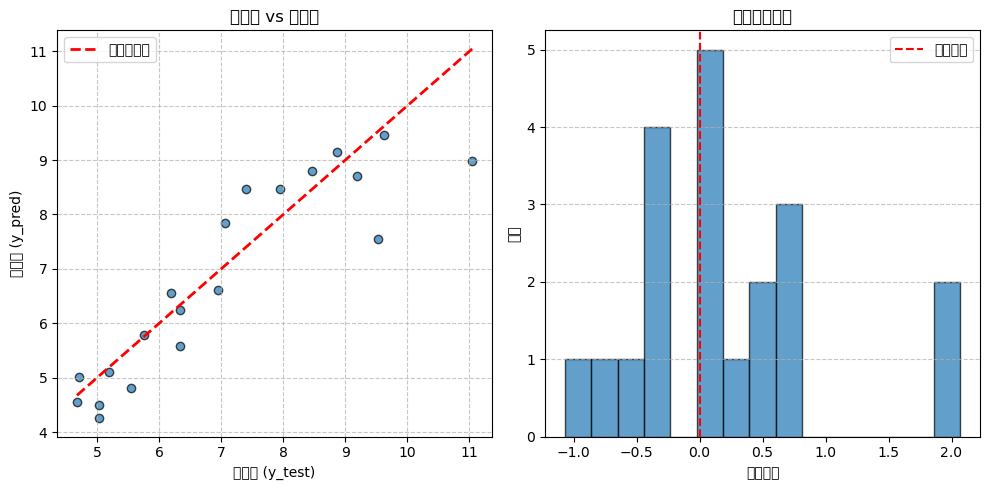

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 创建模拟数据
np.random.seed(42) # 确保每次运行结果一致
X = 2 * np.random.rand(100, 1) # 100个样本，1个特征，范围[0,2)
y = 4 + 3 * X + np.random.randn(100, 1) # 真实关系：y = 4 + 3x + 噪声

# 2. 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 训练一个简单的线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 在测试集上进行预测
y_pred = model.predict(X_test)

# 5. 计算所有评估指标
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # 或者用 mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# 6. 打印评估结果
print("=== 回归模型评估报告 ===")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"决定系数 (R² Score): {r2:.4f}")
print("\n模型系数：")
print(f"   截距 (Intercept): {model.intercept_[0]:.4f}")
print(f"   斜率 (Coefficient for X): {model.coef_[0][0]:.4f}")

# 7. 可视化结果
plt.figure(figsize=(10, 5))

# 子图1：真实值 vs 预测值散点图
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='完美预测线')
plt.xlabel('真实值 (y_test)')
plt.ylabel('预测值 (y_pred)')
plt.title('真实值 vs 预测值')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 子图2：误差分布直方图
plt.subplot(1, 2, 2)
errors = y_test.flatten() - y_pred.flatten()
plt.hist(errors, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', label='零误差线')
plt.xlabel('预测误差')
plt.ylabel('频次')
plt.title('预测误差分布')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7, axis='y')

plt.tight_layout()
plt.show()